# 03d — FINAL Flash-Drought Climatology Indonesia v4

This notebook finalizes the climatology from:

**M2A = FD_BENCHMARK**

## Definition language used in the thesis

M2A is an **adapted, literature-informed soil-moisture-percentile benchmark**.
It combines rapid P40→P20 depletion with an explicit persistence requirement
below P20. It is **not** presented as an exact replication of any one published
flash-drought definition.

The rationale for M2A is methodological:
rapid intensification must be followed by a persistent drought state, reducing
transient P20 threshold crossings.

This notebook does **not** redetect flash drought. It reads the existing M2A
detection and calculates the final spatial/temporal climatology for 1996–2024.

Use the terms:

- detection;
- sensitivity;
- consistency;
- robustness.

Do not call this independent validation.

### Revision 5–6
- Q80/Q90 are now explicitly defined as thresholds of the **valid-grid occurrence distribution**; they are not exact land-area fractions.
- Trend wording is standardized to **“no statistically significant monotonic trend detected”** when p≥0.05.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats

DETECTION_FILE = Path(
    r"D:\ERA5_LAND\output_fd_03b_sensitivity\fd_detection_M2A_1995_2025_indonesia.nc"
)
OUTPUT_DIR = Path(
    r"D:\ERA5_LAND\output_fd_03d_paper_climatology"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_START = 1996
ANALYSIS_END = 2024
YEARS = np.arange(
    ANALYSIS_START,
    ANALYSIS_END + 1,
)

LAT_CHUNK = 40
LON_CHUNK = 50
TIME_CHUNK = 73
FIG_DPI = 300

if not DETECTION_FILE.exists():
    raise FileNotFoundError(DETECTION_FILE)

print("Detection:", DETECTION_FILE)
print("Output   :", OUTPUT_DIR)


Detection: D:\ERA5_LAND\output_fd_03b_sensitivity\fd_detection_M2A_1995_2025_indonesia.nc
Output   : D:\ERA5_LAND\output_fd_03d_paper_climatology


In [2]:
ds = xr.open_dataset(
    DETECTION_FILE,
    chunks={
        "time_index": TIME_CHUNK,
        "latitude": LAT_CHUNK,
        "longitude": LON_CHUNK,
    },
    mask_and_scale=False,
)

required = {
    "fd_event_start",
    "fd_drought_core",
    "duration_pentads_at_start",
    "onset_time_pentads_at_start",
    "below_p20_pentads_at_start",
    "onset_speed_at_start",
    "severity_p40_at_start",
    "minimum_percentile_at_start",
    "valid_grid_mask",
}
missing = required - set(ds.data_vars)
if missing:
    raise KeyError(
        f"Missing variables: {sorted(missing)}"
    )

if (
    "year" not in ds.coords
    or "pentad" not in ds.coords
):
    raise KeyError(
        "Detection file requires year and pentad coordinates."
    )

valid = (
    ds["valid_grid_mask"] == 1
).compute()

year_all = np.asarray(
    ds["year"].values,
    dtype=int,
)
pentad_all = np.asarray(
    ds["pentad"].values,
    dtype=int,
)

idx = np.flatnonzero(
    (year_all >= ANALYSIS_START)
    & (year_all <= ANALYSIS_END)
)

expected = len(YEARS) * 73
if idx.size != expected:
    raise ValueError(
        f"Expected {expected} pentads; found {idx.size}."
    )

d = ds.isel(time_index=idx)

years = np.asarray(
    d["year"].values,
    dtype=int,
)
pentads = np.asarray(
    d["pentad"].values,
    dtype=int,
)

for yr in YEARS:
    if np.sum(years == yr) != 73:
        raise ValueError(
            f"Year {yr} does not contain 73 pentads."
        )

start = (
    d["fd_event_start"] == 1
).where(valid, False)

core = (
    d["fd_drought_core"] == 1
).where(valid, False)

wlat = xr.DataArray(
    np.cos(
        np.deg2rad(
            d["latitude"].values
        )
    ),
    coords={
        "latitude": d["latitude"]
    },
    dims=("latitude",),
)

weights = (
    wlat
    * xr.ones_like(
        valid,
        dtype=np.float32,
    )
).where(valid)

area_den = weights.sum()

print(
    "Valid Indonesia grids:",
    int(valid.sum().item()),
)
print(
    "Analysis:",
    years.min(),
    "-",
    years.max(),
)
print("Pentads:", len(years))


C:\Users\User\AppData\Local\Temp\ipykernel_7504\1896373157.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 40. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(
C:\Users\User\AppData\Local\Temp\ipykernel_7504\1896373157.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 50. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(


Valid Indonesia grids: 14857
Analysis: 1996 - 2024
Pentads: 2117


## 1. Spatial climatology


In [3]:
year_any = []

for yr in YEARS:
    yy = start.where(
        d["year"] == int(yr),
        False,
    )

    year_any.append(
        yy.any("time_index")
        .expand_dims(
            analysis_year=[int(yr)]
        )
    )

year_any = xr.concat(
    year_any,
    dim="analysis_year",
)

metrics_lazy = xr.Dataset({
    "occurrence_probability_percent": (
        year_any.mean("analysis_year")
        * 100.0
    ),
    "events_per_decade": (
        start.sum("time_index")
        / len(YEARS)
        * 10.0
    ),
    "mean_onset_speed_pp_per_pentad": (
        d["onset_speed_at_start"]
        .where(start)
        .mean("time_index")
    ),
    "mean_onset_time_pentads": (
        d["onset_time_pentads_at_start"]
        .where(start)
        .mean("time_index")
    ),
    "mean_total_duration_days": (
        d["duration_pentads_at_start"]
        .where(start)
        .mean("time_index")
        * 5.0
    ),
    "mean_initial_p20_persistence_days": (
        d["below_p20_pentads_at_start"]
        .where(start)
        .mean("time_index")
        * 5.0
    ),
    "mean_severity_p40_pp_pentad": (
        d["severity_p40_at_start"]
        .where(start)
        .mean("time_index")
    ),
    "mean_minimum_rzsm_percentile": (
        d["minimum_percentile_at_start"]
        .where(start)
        .mean("time_index")
    ),
}).where(valid)

print("Computing spatial climatology once...")
metrics = metrics_lazy.compute()

metrics.attrs.update({
    "benchmark_alias": "FD_BENCHMARK",
    "benchmark_definition_role": "adapted literature-informed soil-moisture-percentile benchmark",
    "exact_replication_of_single_published_definition": "false",
    "source_method": "M2A",
    "analysis_period": (
        f"{ANALYSIS_START}-{ANALYSIS_END}"
    ),
    "occurrence_definition": (
        "% complete years with >=1 grid-cell FD onset"
    ),
    "frequency_definition": (
        "grid-cell FD starts normalized per decade"
    ),
})

metric_file = (
    OUTPUT_DIR
    / "fd_benchmark_climatology_metrics_1996_2024.nc"
)
metrics.to_netcdf(metric_file)
print("Saved:", metric_file)


Computing spatial climatology once...
Saved: D:\ERA5_LAND\output_fd_03d_paper_climatology\fd_benchmark_climatology_metrics_1996_2024.nc


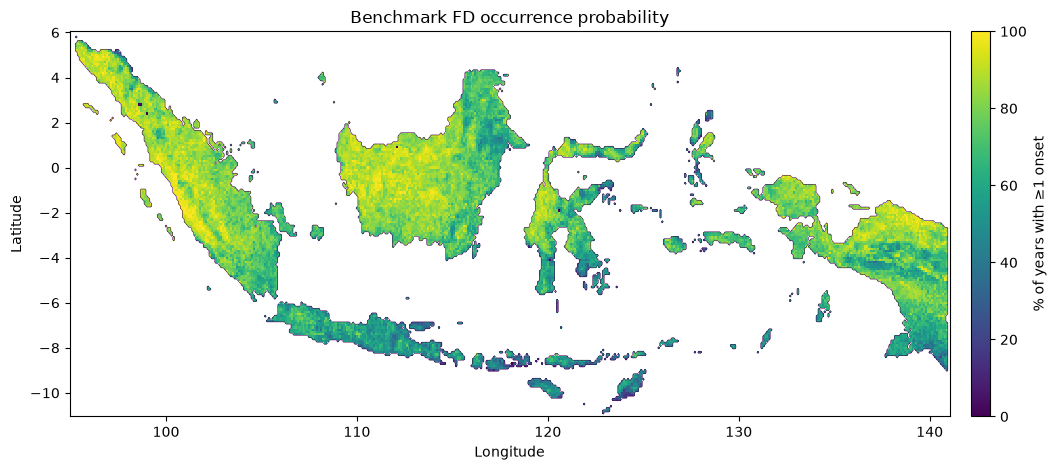

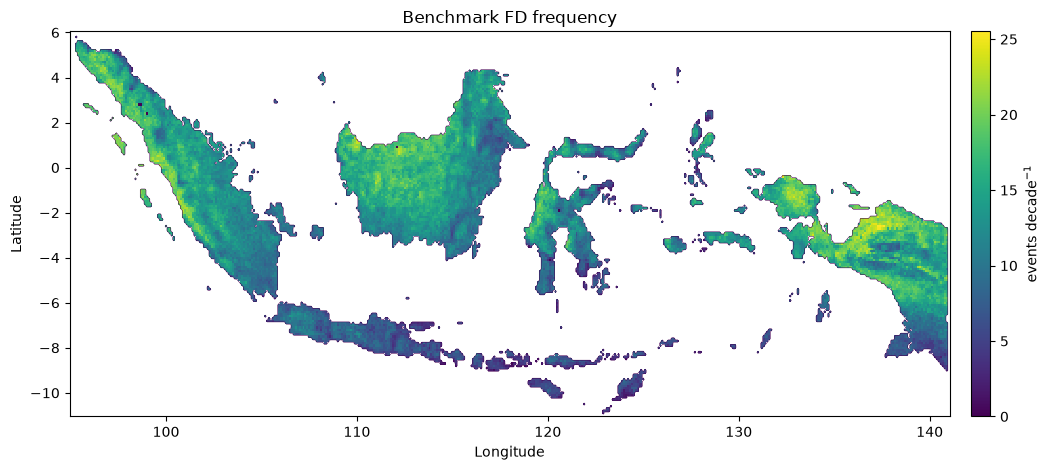

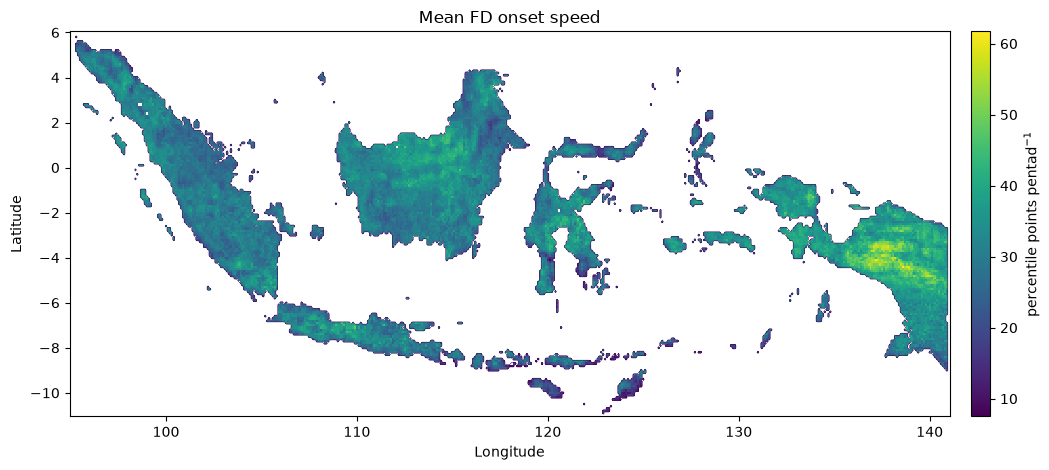

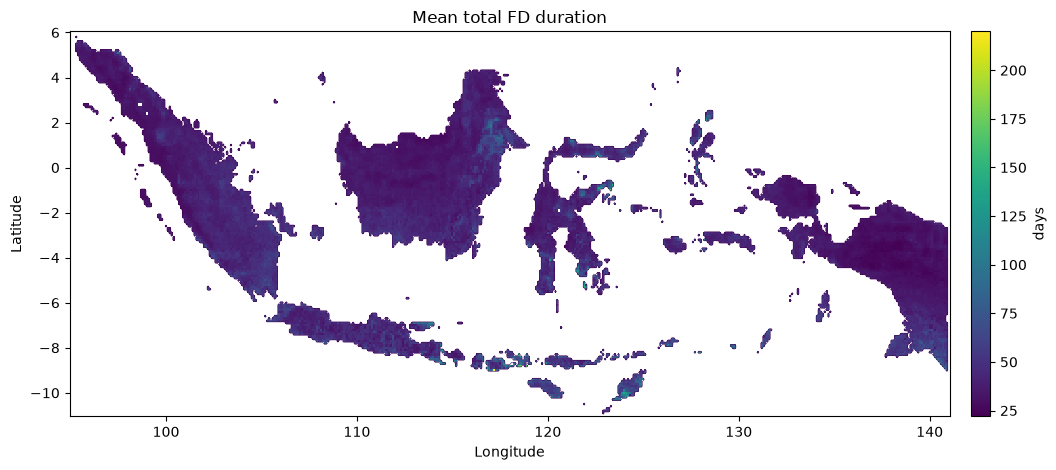

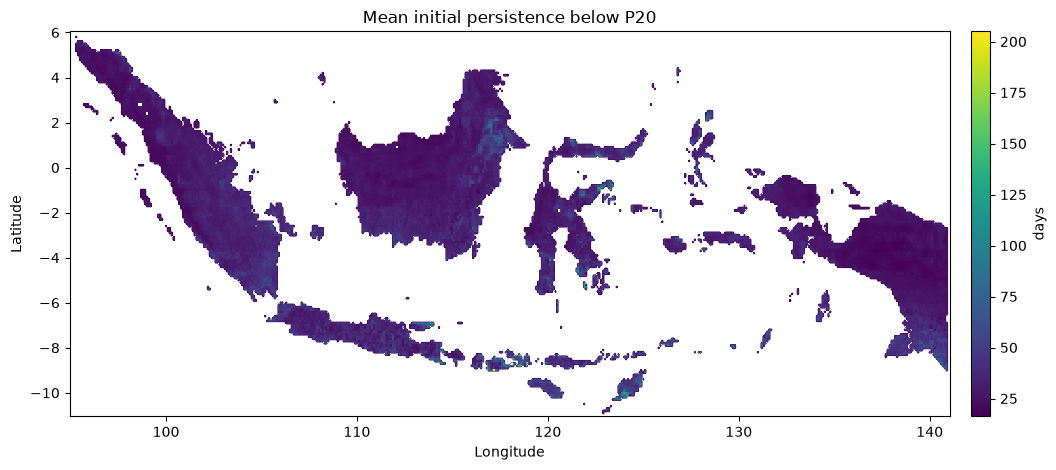

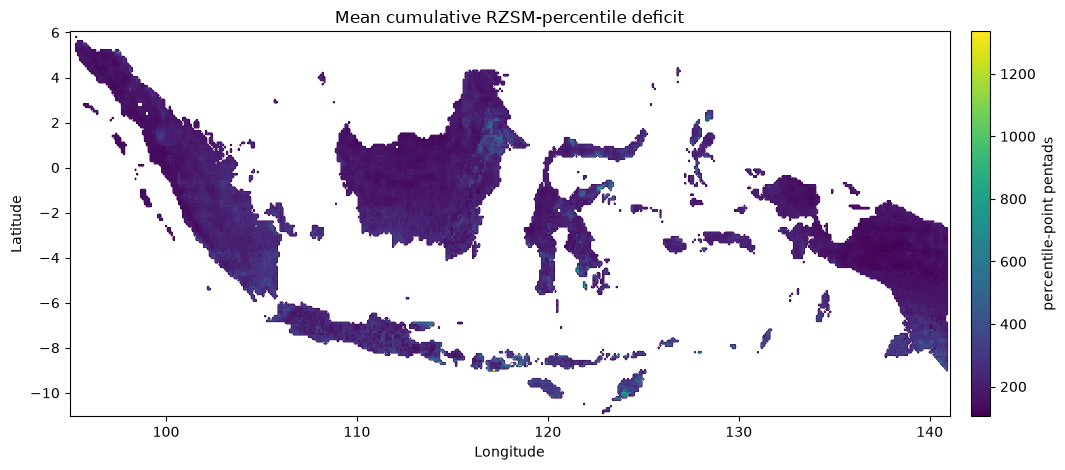

In [4]:
def plot_map(
    da,
    title,
    cbar_label,
    filename,
):
    fig, ax = plt.subplots(
        figsize=(11.5, 4.8)
    )

    im = ax.pcolormesh(
        da["longitude"],
        da["latitude"],
        da,
        shading="auto",
    )

    ax.contour(
        valid["longitude"],
        valid["latitude"],
        valid.astype(int),
        levels=[0.5],
        linewidths=0.4,
    )

    cb = fig.colorbar(
        im,
        ax=ax,
        pad=0.02,
    )
    cb.set_label(cbar_label)

    ax.set(
        xlabel="Longitude",
        ylabel="Latitude",
        title=title,
    )

    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / filename,
        dpi=FIG_DPI,
        bbox_inches="tight",
    )
    plt.show()


map_jobs = [
    (
        "occurrence_probability_percent",
        "Benchmark FD occurrence probability",
        "% of years with ≥1 onset",
        "01_occurrence_probability.png",
    ),
    (
        "events_per_decade",
        "Benchmark FD frequency",
        "events decade$^{-1}$",
        "02_events_per_decade.png",
    ),
    (
        "mean_onset_speed_pp_per_pentad",
        "Mean FD onset speed",
        "percentile points pentad$^{-1}$",
        "03_mean_onset_speed.png",
    ),
    (
        "mean_total_duration_days",
        "Mean total FD duration",
        "days",
        "04_mean_total_duration.png",
    ),
    (
        "mean_initial_p20_persistence_days",
        "Mean initial persistence below P20",
        "days",
        "05_mean_p20_persistence.png",
    ),
    (
        "mean_severity_p40_pp_pentad",
        "Mean cumulative RZSM-percentile deficit",
        "percentile-point pentads",
        "06_mean_severity_p40.png",
    ),
]

for var, title, label, fn in map_jobs:
    plot_map(
        metrics[var],
        title,
        label,
        fn,
    )


## 2. Hotspot sensitivity


In [5]:
occ = (
    metrics["occurrence_probability_percent"]
    .where(valid)
)

vals = occ.values[valid.values]

q80 = float(
    np.nanquantile(vals, 0.80)
)
q90 = float(
    np.nanquantile(vals, 0.90)
)

hotspot_q80 = (
    (occ >= q80)
    .where(valid, False)
    .astype(np.int8)
)

hotspot_q90 = (
    (occ >= q90)
    .where(valid, False)
    .astype(np.int8)
)

# Because occurrence probability is discrete over 29 years,
# ties at the P80/P90 threshold can make the selected fraction
# differ from exactly 20% / 10% of valid grid cells.
q80_selected_grid_percent = float(
    hotspot_q80.where(valid).mean().values
    * 100.0
)

q90_selected_grid_percent = float(
    hotspot_q90.where(valid).mean().values
    * 100.0
)

hotspots = xr.Dataset({
    "hotspot_q80": hotspot_q80,
    "hotspot_q90": hotspot_q90,
})

hotspots.attrs.update({
    "q80_occurrence_threshold_percent": q80,
    "q90_occurrence_threshold_percent": q90,
    "q80_selected_valid_grid_percent": q80_selected_grid_percent,
    "q90_selected_valid_grid_percent": q90_selected_grid_percent,
    "q80_definition": (
        "valid grid cells with occurrence_probability_percent "
        "greater than or equal to the 80th percentile of the "
        "national valid-grid occurrence distribution"
    ),
    "q90_definition": (
        "valid grid cells with occurrence_probability_percent "
        "greater than or equal to the 90th percentile of the "
        "national valid-grid occurrence distribution"
    ),
    "important_note": (
        "P80/P90 refer to percentiles of the grid-cell occurrence "
        "distribution. Because of ties, the masks are not necessarily "
        "exactly 20%/10% of grid cells and must not be described as "
        "20%/10% of Indonesian land area."
    ),
    "severity_note": (
        "Hotspot classification is occurrence-based; "
        "severity remains a separate metric."
    ),
})

hotspots.to_netcdf(
    OUTPUT_DIR
    / "fd_benchmark_hotspot_masks.nc"
)

hotspot_meta = pd.DataFrame([
    {
        "mask": "P80 occurrence",
        "occurrence_threshold_percent": q80,
        "selected_valid_grid_percent": q80_selected_grid_percent,
    },
    {
        "mask": "P90 occurrence",
        "occurrence_threshold_percent": q90,
        "selected_valid_grid_percent": q90_selected_grid_percent,
    },
])

hotspot_meta.to_csv(
    OUTPUT_DIR
    / "hotspot_percentile_threshold_metadata.csv",
    index=False,
)

print(
    "P80 occurrence threshold:",
    q80,
    "| selected valid grids:",
    f"{q80_selected_grid_percent:.2f}%",
)
print(
    "P90 occurrence threshold:",
    q90,
    "| selected valid grids:",
    f"{q90_selected_grid_percent:.2f}%",
)
print(
    "Interpretation: ≥P90 of grid-cell occurrence distribution; "
    "NOT exact top 10% land area."
)


P80 occurrence threshold: 86.20689655172413 | selected valid grids: 28.83%
P90 occurrence threshold: 89.65517241379311 | selected valid grids: 18.24%
Interpretation: ≥P90 of grid-cell occurrence distribution; NOT exact top 10% land area.


## 3. Seasonality and annual area metrics


In [6]:
print("Computing national onset/core area series once...")

area = xr.Dataset({
    "onset_area_percent": (
        (
            start.astype(np.float32)
            * weights
        )
        .sum(("latitude", "longitude"))
        / area_den
        * 100.0
    ),
    "core_area_percent": (
        (
            core.astype(np.float32)
            * weights
        )
        .sum(("latitude", "longitude"))
        / area_den
        * 100.0
    ),
}).compute()

frame = pd.DataFrame({
    "year": years,
    "pentad": pentads,
    "onset_area_percent": (
        area["onset_area_percent"].values
    ),
    "core_area_percent": (
        area["core_area_percent"].values
    ),
})

ref = pd.Timestamp("2001-01-01")
mid_doy = (
    (frame["pentad"] - 1)
    * 5
    + 3
)

frame["month"] = [
    (
        ref
        + pd.Timedelta(
            days=int(x) - 1
        )
    ).month
    for x in mid_doy
]

pentad_clim = (
    frame.groupby(
        "pentad",
        as_index=False,
    )["onset_area_percent"]
    .mean()
)

pentad_clim.to_csv(
    OUTPUT_DIR
    / "seasonal_mean_onset_area_by_pentad.csv",
    index=False,
)

year_month = (
    frame.groupby(
        ["year", "month"],
        as_index=False,
    )["onset_area_percent"]
    .sum()
)

monthly = (
    year_month.groupby(
        "month",
        as_index=False,
    )["onset_area_percent"]
    .mean()
    .rename(columns={
        "onset_area_percent":
        "mean_onset_area_percent_pentad_sum"
    })
)

monthly["contribution_percent"] = (
    monthly[
        "mean_onset_area_percent_pentad_sum"
    ]
    / monthly[
        "mean_onset_area_percent_pentad_sum"
    ].sum()
    * 100.0
)

monthly.to_csv(
    OUTPUT_DIR
    / "seasonal_monthly_onset_contribution.csv",
    index=False,
)

annual_rows = []

for yr in YEARS:
    sub = frame[
        frame["year"] == int(yr)
    ]

    max_core_idx = (
        sub["core_area_percent"]
        .idxmax()
    )

    annual_rows.append({
        "year": int(yr),
        "annual_onset_exposure_area_percent_pentad": float(
            sub["onset_area_percent"].sum()
        ),
        "maximum_new_onset_area_percent": float(
            sub["onset_area_percent"].max()
        ),
        "maximum_drought_core_area_percent": float(
            sub["core_area_percent"].max()
        ),
        "pentad_of_maximum_core_area": int(
            sub.loc[
                max_core_idx,
                "pentad",
            ]
        ),
    })

annual = pd.DataFrame(annual_rows)

annual.to_csv(
    OUTPUT_DIR
    / "annual_spatial_metrics_1996_2024.csv",
    index=False,
)

display(monthly)
display(
    annual.sort_values(
        "maximum_drought_core_area_percent",
        ascending=False,
    ).head(10)
)


Computing national onset/core area series once...


,month,mean_onset_area_percent_pentad_sum,contribution_percent
0,1,12.785852,9.836670
1,2,13.613110,10.473114
2,3,13.589496,10.454946
3,4,13.184319,10.143227
4,5,16.536224,12.721982
5,6,12.308364,9.469320
6,7,6.718623,5.168907
7,8,6.785321,5.220220
8,9,5.595213,4.304623
9,10,6.152368,4.733264


,year,annual_onset_exposure_area_percent_pentad,maximum_new_onset_area_percent,maximum_drought_core_area_percent,pentad_of_maximum_core_area
7,2003,178.890249,33.643204,81.419568,33
1,1997,173.842476,25.371600,69.897383,32
19,2015,158.654566,25.678279,69.548994,39
18,2014,131.261728,24.145610,55.171887,8
6,2002,204.234679,25.435192,51.557238,30
13,2009,148.928641,20.335220,49.852690,25
27,2023,127.128091,11.699482,49.587784,2
12,2008,126.359665,16.503583,48.965899,29
8,2004,223.691700,32.380994,48.140909,36
5,2001,156.207581,18.446987,45.900094,39


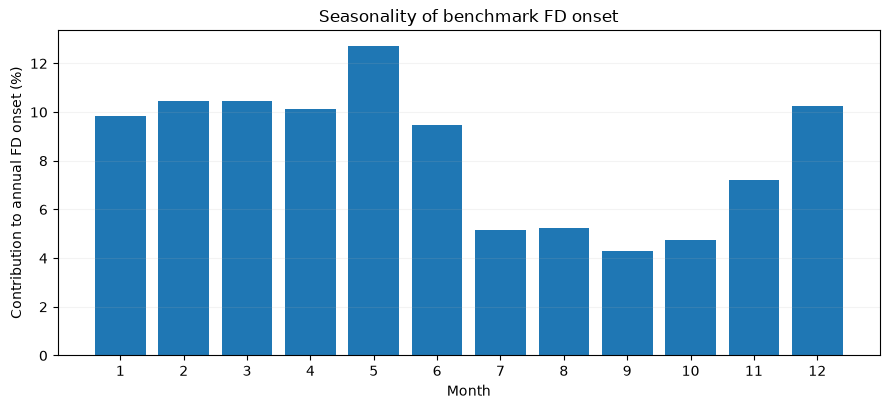

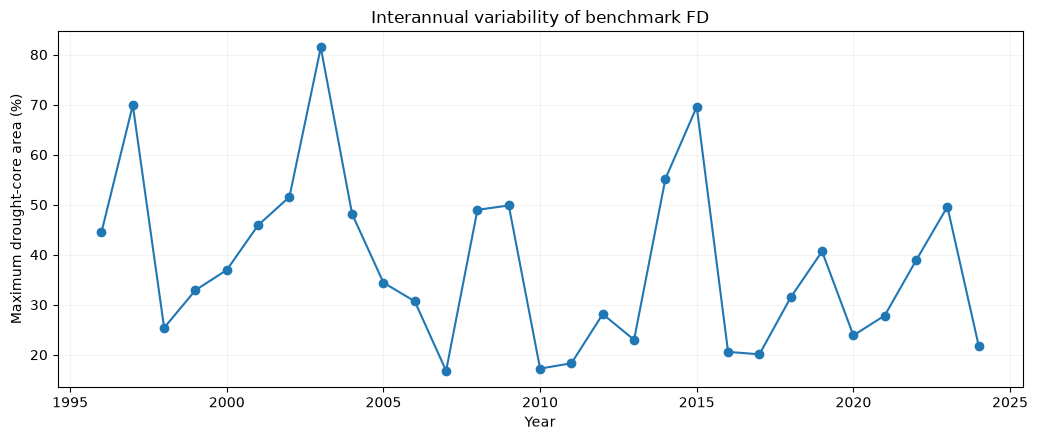

In [7]:
fig, ax = plt.subplots(
    figsize=(9, 4.2)
)

ax.bar(
    monthly["month"],
    monthly["contribution_percent"],
)

ax.set_xticks(
    range(1, 13)
)

ax.set(
    xlabel="Month",
    ylabel="Contribution to annual FD onset (%)",
    title="Seasonality of benchmark FD onset",
)

ax.grid(
    axis="y",
    alpha=0.15,
)

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR
    / "07_monthly_onset_seasonality.png",
    dpi=FIG_DPI,
    bbox_inches="tight",
)
plt.show()


fig, ax = plt.subplots(
    figsize=(10.5, 4.5)
)

ax.plot(
    annual["year"],
    annual[
        "maximum_drought_core_area_percent"
    ],
    marker="o",
)

ax.set(
    xlabel="Year",
    ylabel="Maximum drought-core area (%)",
    title="Interannual variability of benchmark FD",
)

ax.grid(alpha=0.15)

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR
    / "08_annual_maximum_core_area.png",
    dpi=FIG_DPI,
    bbox_inches="tight",
)
plt.show()


## 4. Trend screening

Trend screening uses Kendall's tau against year and a Theil–Sen slope.

### Required wording

If `p >= 0.05`, report:

> **No statistically significant monotonic trend was detected** in the tested
> national FD-area metric during 1996–2024.

Do **not** shorten this to “there is no trend”.

The test evaluates evidence for a monotonic trend over this finite record.
No pre-whitening / serial-autocorrelation correction is applied here, so the
p-values are treated as **screening-level evidence** rather than a definitive
trend-attribution result.


In [8]:
def trend_test(column):
    x = annual["year"].to_numpy(
        dtype=float
    )
    y = annual[column].to_numpy(
        dtype=float
    )

    tau, p = stats.kendalltau(
        x,
        y,
        nan_policy="omit",
    )

    slope, intercept, lo, hi = (
        stats.theilslopes(
            y,
            x,
            alpha=0.95,
        )
    )

    significant = bool(p < 0.05)

    return {
        "metric": column,
        "kendall_tau": float(tau),
        "p_value": float(p),
        "theil_sen_slope_per_year": float(slope),
        "slope_ci95_low": float(lo),
        "slope_ci95_high": float(hi),
        "significant_monotonic_trend_p05": significant,
        "interpretation_p05": (
            "statistically significant monotonic trend detected"
            if significant
            else "no statistically significant monotonic trend detected"
        ),
        "inference_scope": (
            "screening-level; no serial-autocorrelation/pre-whitening correction"
        ),
    }


trend = pd.DataFrame([
    trend_test(
        "annual_onset_exposure_area_percent_pentad"
    ),
    trend_test(
        "maximum_new_onset_area_percent"
    ),
    trend_test(
        "maximum_drought_core_area_percent"
    ),
])

trend.to_csv(
    OUTPUT_DIR
    / "annual_trend_screening.csv",
    index=False,
)

display(trend)

if not trend["significant_monotonic_trend_p05"].any():
    print(
        "FINAL WORDING: No statistically significant monotonic trend "
        "was detected in the tested national FD-area metrics during "
        f"{ANALYSIS_START}–{ANALYSIS_END}."
    )


,metric,kendall_tau,p_value,theil_sen_slope_per_year,slope_ci95_low,slope_ci95_high,significant_monotonic_trend_p05,interpretation_p05,inference_scope
0,annual_onset_exposure_area_percent_pentad,-0.192118,0.149786,-1.579939,-3.698626,0.535701,False,no statistically significant monotonic trend d...,screening-level; no serial-autocorrelation/pre...
1,maximum_new_onset_area_percent,-0.241379,0.068527,-0.287958,-0.654081,0.018699,False,no statistically significant monotonic trend d...,screening-level; no serial-autocorrelation/pre...
2,maximum_drought_core_area_percent,-0.147783,0.271070,-0.493338,-1.194158,0.303888,False,no statistically significant monotonic trend d...,screening-level; no serial-autocorrelation/pre...


FINAL WORDING: No statistically significant monotonic trend was detected in the tested national FD-area metrics during 1996–2024.


## 5. Event-characteristic summary


In [9]:
rows = []

for var, unit in [
    (
        "onset_speed_at_start",
        "percentile points pentad-1",
    ),
    (
        "onset_time_pentads_at_start",
        "pentads",
    ),
    (
        "duration_pentads_at_start",
        "pentads",
    ),
    (
        "below_p20_pentads_at_start",
        "pentads",
    ),
    (
        "severity_p40_at_start",
        "percentile-point pentads",
    ),
    (
        "minimum_percentile_at_start",
        "percentile",
    ),
]:
    vals = (
        d[var]
        .where(start)
        .stack(
            sample=(
                "time_index",
                "latitude",
                "longitude",
            )
        )
        .dropna("sample")
        .compute()
        .values
    )

    rows.append({
        "variable": var,
        "unit": unit,
        "n_gridcell_events": int(vals.size),
        "mean": float(np.mean(vals)),
        "median": float(np.median(vals)),
        "q25": float(
            np.quantile(vals, 0.25)
        ),
        "q75": float(
            np.quantile(vals, 0.75)
        ),
    })

summary = pd.DataFrame(rows)

summary.to_csv(
    OUTPUT_DIR
    / "benchmark_event_characteristics_summary.csv",
    index=False,
)

display(summary)


,variable,unit,n_gridcell_events,mean,median,q25,q75
0,onset_speed_at_start,percentile points pentad-1,559676,32.961132,30.526993,19.280205,41.773781
1,onset_time_pentads_at_start,pentads,559676,1.720956,2.000000,1.000000,2.000000
2,duration_pentads_at_start,pentads,559676,7.648331,6.000000,5.000000,8.000000
3,below_p20_pentads_at_start,pentads,559676,5.927374,4.000000,3.000000,6.000000
4,severity_p40_at_start,percentile-point pentads,559676,195.640594,133.161957,101.388176,196.349609
5,minimum_percentile_at_start,percentile,559676,5.382042,5.012854,1.799486,8.226221


In [10]:
manifest = {
    "benchmark": "M2A -> FD_BENCHMARK",
    "analysis_period": [
        ANALYSIS_START,
        ANALYSIS_END,
    ],
    "valid_grid_count": int(
        valid.sum().item()
    ),
    "guardrail": (
        "Grid-cell event starts are not "
        "independent regional events."
    ),
}

(
    OUTPUT_DIR
    / "manifest_03d_final.json"
).write_text(
    json.dumps(
        manifest,
        indent=2,
    ),
    encoding="utf-8",
)

ds.close()
print(
    "03d FINAL complete:",
    OUTPUT_DIR,
)


03d FINAL complete: D:\ERA5_LAND\output_fd_03d_paper_climatology
